# Code used to process data and create figures in "Evaluation of collaborative methods of subsurface temperature monitoring aboard commercial fishing vessels in the Mid-Atlantic Bight"
### Mary Kate Munley<sup>1</sup>., Haley Synan<sup>1*</sup>, George Maynard<sup>2</sup>, Anna Mercer<sup>1</sup>, Sarah Salois<sup>1</sup>, Kimberly Hyde<sup>1</sup>
<sup>1</sup>NOAA Northeast Fisheries Science Center, Narragansett, RI, USA <br>
<sup>2</sup>NOAA Northeast Fisheries Science Center, Woods Hole, MA, USA <br>
<sup>*</sup>Code author 
### History: <br>
> * *9/2025: Code initiated by HS*
> * *10/2025: Statistical tests chosen & finalized*
> * *2/2026: Added functions for calculating descent rate and time delays between methodologies*
> * *3/2026: Added comments and cleaned up code*
> * *4/2026: Added ability to pull data directly from github*

### Objectives: 
* Create figures and statistical analysis used in Munley et al 2026. 

### Dependencies:
* In addition to this jupyter notebook, specific functions written for this processing are found in [```functions.py```](https://github.com/hsynan/sensor_comps/blob/main/CODE/functions.py)
* Access to the raw data is available [HERE]()
 
### Table of Contents: 
* Load data
* Find length of fishing tows 
* Process data
    * Remove top decibar from each profile (equilibration phase)
    * Split into directional casts (up/downcasts)
    * Calculate descent rate
    * Average into 1 m pressure bins
* Aggregate all data
* Get time difference between profiles
* Visualize all profiles
* Remove problematic profiles
* Statistical analysis and Bland-Altman Plot

In [1]:
import os
import ctd
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
from seabird.cnv import fCNV
from collections import Counter
from datetime import datetime, timedelta
from itertools import combinations
import warnings
import gsw
import statistics

from functions import calculate_mbe
from functions import load_data
from functions import merge
from functions import bland_altman_plot
from functions import timelag_correction
from functions import bin_merge_2
from functions import bin_merge_4
from functions import format_dates
from functions import format_raw
from functions import get_fnames
from functions import split_cast
from functions import subset_tows
from functions import pres_bin
from functions import process_casts
from functions import process_rbr 
from functions import get_descent_rate

def merge(sbe_up, ecage_up, edoors_up, rbr_up,var='temp'):
    merged = pd.merge(sbe_up, ecage_up, on='binned_pres', how='inner')
    merged = merged.rename(columns={var+'_x':var+'_sbe',var+'_y':var+'_ecage','datetime_x':'datetime_sbe','datetime_y':'datetime_ecage'})[[var+'_sbe',var+'_ecage','binned_pres','datetime_sbe','datetime_ecage']]
    merged = pd.merge(merged, edoors_up, on='binned_pres', how='inner').rename(columns={var:var+'_edoors','datetime':'datetime_edoors'})[['binned_pres',var+'_sbe',var+'_ecage',var+'_edoors','datetime_sbe','datetime_ecage','datetime_edoors']]
    merged = pd.merge(merged, rbr_up, on='binned_pres', how='inner').rename(columns={var:var+'_rbr','datetime':'datetime_rbr',})[['binned_pres',var+'_sbe',var+'_ecage',var+'_edoors',var+'_rbr','datetime_sbe','datetime_ecage','datetime_edoors','datetime_rbr','station','cruise_ID']]
    return merged

In [2]:
# create dictionaries for descent rate
sbe_dr = {} #sbe descent rate (winch)
rbr_dr = {} #rbr descent rate (headrope)
rbr_w = {} #rbr descent rate from WINCH (supplementary 2025)
ecage_dr = {} #emolt winch descent rate
edoors_dr = {} #emolt doors descent rate 

In [3]:
#open data
#these have already been split into 
rbr_all = pd.read_csv(r'https://raw.githubusercontent.com/hsynan/PEMAD-CRB_Munley_Sensor_Deployment_Fishing_Vessels/refs/heads/main/data/RBR_headrope.csv.gz')
sbe_all = pd.read_csv(r'https://raw.githubusercontent.com/hsynan/PEMAD-CRB_Munley_Sensor_Deployment_Fishing_Vessels/refs/heads/main/data/SBE_winch.csv')
ecage_all = pd.read_csv(r'https://raw.githubusercontent.com/hsynan/PEMAD-CRB_Munley_Sensor_Deployment_Fishing_Vessels/refs/heads/main/data/TDO1_winch.csv')
edoors_all = pd.read_csv(r'https://raw.githubusercontent.com/hsynan/PEMAD-CRB_Munley_Sensor_Deployment_Fishing_Vessels/refs/heads/main/data/TDO1_doors.csv')

C:\Users\haley.synan\AppData\Local\Temp\ipykernel_17748\2740816252.py:3: DtypeWarning: Columns (5) have mixed types. Specify dtype option on import or set low_memory=False.
  rbr_all = pd.read_csv(r'https://raw.githubusercontent.com/hsynan/PEMAD-CRB_Munley_Sensor_Deployment_Fishing_Vessels/refs/heads/main/data/RBR_headrope.csv.gz')


## Get minimum and maximum length of tows 

In [4]:
groupedd= rbr_all
grouped =groupedd.groupby(['station','cruise_ID'])
tim={}
for name, group in grouped:
    if name[1]=='SUP_2025':
        pass
    else:
        if name ==(10.0, 'IFS_2025'): 
            #issue with RBR not turning off
            pass
        else: 
            tim.update({name:(pd.to_datetime(group.datetime.max())-pd.to_datetime(group.datetime.min())).total_seconds()/60})


for name, group in grouped:
    if name[1]=='SUP_2025':
        pass
    else:
        if name ==(10.0, 'IFS_2025'): 
            #issue with RBR not turning off
            pass
        else: 
            if tim[name] > (pd.to_datetime(group.datetime.max())-pd.to_datetime(group.datetime.min())).total_seconds()/60:
                tim.update({name:(pd.to_datetime(group.datetime.max())-pd.to_datetime(group.datetime.min())).total_seconds()/60})

max_key = max(tim, key=tim.get)
max_value = tim[max_key]

min_key = min(tim, key=tim.get)
min_value = tim[min_key]
print(f'The shortest tow was {min_value} minutes at station {min_key[0]} on the {min_key[1]} fishing trip')
print(f'The longest tow was {max_value} minutes at station {max_key[0]} on the {max_key[1]} fishing trip')

The shortest tow was 73.3125 minutes at station 6.0 on the IFS_2025 fishing trip
The longest tow was 190.56875 minutes at station 11.0 on the IFS_2025 fishing trip


In [5]:
#data cleaning
sbe_all = sbe_all[sbe_all.pres>1]
rbr_all = rbr_all[rbr_all.pres>1]
ecage_all = ecage_all[ecage_all.pres>1]
edoors_all = edoors_all[edoors_all.pres>1]

sbe_all['datetime']=pd.to_datetime(sbe_all.datetime)
ecage_all['datetime']=pd.to_datetime(ecage_all.datetime)
rbr_all['datetime']=pd.to_datetime(rbr_all.datetime)
edoors_all['datetime']=pd.to_datetime(edoors_all.datetime)

rbr_all['station'] = rbr_all['station'].astype(float)

## Process data 
For each profile:
* Split into directional casts (down, tow, up)
* Get descent rate on raw pressure data
* Put into 1 meter pressure bins

### June 2024 fishing trip

In [6]:
dat=[]
# OPEN 2024 IFS DATA
sbe_c = sbe_all[sbe_all.cruise_ID=='IFS_2024']
rbr_c = rbr_all[rbr_all.cruise_ID=='IFS_2024']
for xx in rbr_c.station.unique()[~np.isnan(rbr_c.station.unique())]: #loop through stations 
    #load data 
    sbe = sbe_c[sbe_c.station==xx]
    rbr= rbr_c[rbr_c.station==xx]
    
    #split into up/down casts 
    rbr_down =rbr[rbr['tow'].str.contains('-A')]
    rbr_tow =rbr[rbr['tow'].str.contains('-B')]
    rbr_up =rbr[rbr['tow'].str.contains('-C')]
    sbe_down, sbe_up = split_cast(sbe) #vertical

    #get descent rate (up for sbe, down for rbr)
    sbe_dr.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(sbe_up.pres.max()-sbe_up.pres.min())/(sbe_up.datetime.max()-sbe_up.datetime.min()).total_seconds()})
    rbr_dr.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(rbr_down.pres.max()-rbr_down.pres.min())/(rbr_down.datetime.max()-rbr_down.datetime.min()).total_seconds()})
   
    #1 m bins 
    rbr_down, rbr_up = pres_bin(rbr_down),pres_bin(rbr_up)
    sbe_down, sbe_up = pres_bin(sbe_down),pres_bin(sbe_up)
     #merge 
    mixed_merged = pd.merge(sbe_up, rbr_down,on='binned_pres', how='inner')
    mixed_merged_24 = mixed_merged.rename(columns={'cruise_ID_x':'cruise_ID','temp_x':'temp_sbe','temp_y':'temp_rbr','datetime_x':'datetime_sbe','datetime_y':'datetime_rbr','station_x':'station'})
    mixed_merged_24['temp_ecage'] = float('nan')
    mixed_merged_24['temp_edoors']= float('nan')
    mixed_merged_24['datetime_ecage'] = float('nan')
    mixed_merged_24['datetime_edoors'] = float('nan')
    dat.append(mixed_merged_24[['binned_pres', 'temp_sbe', 'temp_ecage', 'temp_edoors', 'temp_rbr',
       'datetime_sbe', 'datetime_ecage',
       'datetime_edoors', 'datetime_rbr', 'station', 'cruise_ID']])

### June 2025 fishing trip

In [7]:
# OPEN 2025 IFS DATA
sbe_c = sbe_all[sbe_all.cruise_ID=='IFS_2025']
rbr_c = rbr_all[rbr_all.cruise_ID=='IFS_2025']
ecage_c = ecage_all[ecage_all.cruise_ID=='IFS_2025']
edoors_c = edoors_all[edoors_all.cruise_ID=='IFS_2025']
for xx in rbr_c.station.unique()[~np.isnan(rbr_c.station.unique())]: #loop through stations 
    #load data 
    sbe = sbe_c[sbe_c.station==xx]
    rbr= rbr_c[rbr_c.station==xx]
    ecage = ecage_c[ecage_c.station==xx]
    edoors= edoors_c[edoors_c.station==xx]
    
    #split into up/down casts 
    rbr_down =rbr[rbr['tow'].str.contains('-A')]
    rbr_tow =rbr[rbr['tow'].str.contains('-B')]
    rbr_up =rbr[rbr['tow'].str.contains('-C')]
    edoors = subset_tows(edoors) #create up, down, and tow casts
    edoors_up = edoors[edoors.tow=='C']
    edoors_down = edoors[edoors.tow=='A'] 
    sbe_down, sbe_up = split_cast(sbe) #vertical
    ecage_down, ecage_up = split_cast(ecage) #vertical
    
    #get descent rate (up for sbe, down for rbr)
    sbe_dr.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(sbe_up.pres.max()-sbe_up.pres.min())/(sbe_up.datetime.max()-sbe_up.datetime.min()).total_seconds()})
    rbr_dr.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(rbr_down.pres.max()-rbr_down.pres.min())/(rbr_down.datetime.max()-rbr_down.datetime.min()).total_seconds()})
    ecage_dr.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(ecage_down.pres.max()-ecage_down.pres.min())/(ecage_down.datetime.max()-ecage_down.datetime.min()).total_seconds()})
    edoors_dr.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(edoors_down.pres.max()-edoors_down.pres.min())/(edoors_down.datetime.max()-edoors_down.datetime.min()).total_seconds()})
    
    #1 m bins 
    rbr_down, rbr_up = pres_bin(rbr_down),pres_bin(rbr_up)
    sbe_down, sbe_up = pres_bin(sbe_down),pres_bin(sbe_up)
    ecage_down, ecage_up = pres_bin(ecage_down), pres_bin(ecage_up)
    edoors_down, e_doors_up = pres_bin(edoors_down), pres_bin(edoors_up)

    #merge 
    mixed_merged_25 = merge(sbe_up, ecage_up, edoors_down, rbr_down)
    dat.append(mixed_merged_25)

### August 2025 fishing trip

In [8]:
# OPEN 2025 SUP DATA
sbe_c = sbe_all[sbe_all.cruise_ID=='SUP_2025']
rbr_c = rbr_all[rbr_all.cruise_ID=='SUP_2025']
ecage_c = ecage_all[ecage_all.cruise_ID=='SUP_2025']
#edoors_c = edoors_all[edoors_all.cruise_ID=='SUP_2025']

for xx in rbr_c.station.unique()[~np.isnan(rbr_c.station.unique())]: #loop through stations 
    #load data 
    sbe = sbe_c[sbe_c.station==xx]
    rbr = rbr_c[rbr_c.station==xx]
    ecage = ecage_c[ecage_c.station==xx]
    
    #split into up/down casts 
    rbr_down,rbr_up = split_cast(rbr) #vertical 
    sbe_down, sbe_up = split_cast(sbe) #vertical
    ecage_down, ecage_up = split_cast(ecage) #vertical
    
    #get descent rate (up for all!)
    sbe_dr.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(sbe_up.pres.max()-sbe_up.pres.min())/(sbe_up.datetime.max()-sbe_up.datetime.min()).total_seconds()})
    rbr_w.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(rbr_down.pres.max()-rbr_down.pres.min())/(rbr_down.datetime.max()-rbr_down.datetime.min()).total_seconds()})
    ecage_dr.update({f'{sbe.iloc[0].cruise_ID+'_'+str(xx)}':(ecage_down.pres.max()-ecage_down.pres.min())/(ecage_down.datetime.max()-ecage_down.datetime.min()).total_seconds()})
    
    #1 m bins 
    rbr_down, rbr_up = pres_bin(rbr_down),pres_bin(rbr_up)
    sbe_down, sbe_up = pres_bin(sbe_down),pres_bin(sbe_up)
    ecage_down, ecage_up = pres_bin(ecage_down), pres_bin(ecage_up)
    edoors_up = pd.DataFrame({'datetime':[float('nan')] * len(sbe_up),'temp':[float('nan')] * len(sbe_up),'binned_pres':sbe_up.binned_pres})

    #merge 
    mixed_merged_25_s = merge(sbe_up, ecage_up, edoors_up, rbr_up)
    dat.append(mixed_merged_25_s)

## Calculate average descent rate by deployment methodology

In [9]:
#Get average descent rates 
all_winch = list(rbr_w.values())+list(sbe_dr.values())+list(ecage_dr.values())
#print(f'The Seabird 19+ average descent rate is: {statistics.mean(sbe_dr.values())} m/s')
print(f'The headrope deployment method average descent rate is: {round(statistics.mean(rbr_dr.values()),3)} m/s,  with a std of {round(statistics.stdev(rbr_dr.values()),3)}')
#print(f'The eMOLT winch average descent rate is: {statistics.mean(ecage_dr.values())} m/s')
print(f'The doors deployment method average descent rate is: {round(statistics.mean(edoors_dr.values()),3)} m/s,  with a std of {round(statistics.stdev(edoors_dr.values()),3)}')
print(f'The winch deployment method average descent rate is: {round(statistics.mean(all_winch),3)} m/s, with a std of {round(statistics.stdev(all_winch),3)}')


The headrope deployment method average descent rate is: 0.15 m/s,  with a std of 0.047
The doors deployment method average descent rate is: 0.389 m/s,  with a std of 0.122
The winch deployment method average descent rate is: 0.67 m/s, with a std of 0.238


## Aggregate all data 
Round to each instrument's precision before applying a derivative-based lag correction. This corrects for the misalignment between the different sensor's reponse times. After, round all data to 1 decimal to match the TDO-1, which has the lowest precision. 

In [10]:
data = pd.concat(dat).reset_index(drop=True) #concatenate all data
data = data[data.binned_pres!=0]


#ROUND TO EACH INSTRUMENTS PRECISION
temp_sbe = data.temp_sbe.round(3) 
temp_rbr = data.temp_rbr.round(3)
temp_ecage = data.temp_ecage.round(1).dropna().reset_index(drop=True)
temp_edoors = data.temp_edoors.round(1).dropna().reset_index(drop=True)


#APPLY TIME LAG CORRECTION 
#correct for response time lags
data['temp_sbe'] = timelag_correction(temp_sbe, data.datetime_sbe, 0.5)
data['temp_rbr'] = timelag_correction(temp_rbr, data.datetime_rbr, 0.1)
data[data.temp_ecage.notna()]['temp_ecage'] = timelag_correction(temp_ecage, data.datetime_ecage.dropna().reset_index(drop=True), 1)
data[data.temp_edoors.notna()]['temp_edoors'] = timelag_correction(temp_edoors, data.datetime_edoors.dropna().reset_index(drop=True), 1)

#VISUALIZE

#round to 1 decimal place
data[data.columns[data.columns.str.contains('temp', case=False, regex=True)]]= data.loc[:, data.columns.isin(data.columns[data.columns.str.contains('temp', case=False, regex=True)].tolist())].round(1)
data[data.columns[data.columns.str.contains('sal', case=False, regex=True)]]= data.loc[:, data.columns.isin(data.columns[data.columns.str.contains('sal', case=False, regex=True)].tolist())].round(3)

#REMOVE EDOORS SUPPLEMENTARY --> data is not from the same cruise  ]
data.loc[data['cruise_ID'] == 'SUP_2025', 'temp_edoors'] = np.nan


C:\Users\haley.synan\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1242: RuntimeWarning: divide by zero encountered in divide
  a = -(dx2)/(dx1 * (dx1 + dx2))
C:\Users\haley.synan\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1243: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
C:\Users\haley.synan\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1244: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
C:\Users\haley.synan\AppData\Local\anaconda3\Lib\site-packages\numpy\lib\function_base.py:1250: RuntimeWarning: invalid value encountered in add
  out[tuple(slice1)] = a * f[tuple(slice2)] + b * f[tuple(slice3)] + c * f[tuple(slice4)]


## Get time differences between deployment methdologies

In [11]:
#GET TIME DIFFERENCES 
data.loc[data.cruise_ID=='SUP_2025','datetime_edoors']=np.nan #set Supplementary edoors to nan as they dont match
grouped = data.groupby(['station','cruise_ID'])

timedif_cruise=[]
timedif_sup=[]
for group_name, group_df in grouped: 
    all_times=group_df[['datetime_sbe',	'datetime_ecage','datetime_edoors',	'datetime_rbr']].iloc[1] #get first 
    if group_name[1]!='SUP_2025':
        timedif_cruise.append(all_times.max()-all_times.min())
    if group_name[1]=='SUP_2025':
        timedif_sup.append(all_times.max()-all_times.min())


print(f'The minimum time delay for cruises is {np.array(timedif_cruise).min()}')
print(f'The maximum time delay for cruises is {np.array(timedif_cruise).max()}')
print(f'The average time delay for cruises is {np.array(timedif_cruise).mean()}')
#print(f'The minimum time delay is {np.array(timedif_cruise).min()} from station {list(sensordif.keys())[np.array(timedif).argmin()].split('(')[1].split(',')[0]} on the {list(sensordif.keys())[np.array(timedif).argmin()].split('(')[1].split(',')[1].split("'")[1]} cruise')
#print(f'The maximum time delay is {np.array(timedif).max()} from station {list(sensordif.keys())[np.array(timedif).argmax()].split('(')[1].split(',')[0]} on the {list(sensordif.keys())[np.array(timedif).argmax()].split('(')[1].split(',')[1].split("'")[1]} cruise')
print(f'The minimum time delay for supplementary data (all from winch simultaneously) is {np.array(timedif_sup).min()}')
print(f'The maximum time delay for supplementary data (all from winch simultaneously) is {np.array(timedif_sup).max()}')
print(f'The average time delay for supplementary data (all from winch simultaneously) is {np.array(timedif_sup).mean()}')

The minimum time delay for cruises is 0 days 00:11:43.352183040
The maximum time delay for cruises is 0 days 00:32:24.864480
The average time delay for cruises is 0 days 00:17:29.738687251
The minimum time delay for supplementary data (all from winch simultaneously) is 0 days 00:00:12.500500224
The maximum time delay for supplementary data (all from winch simultaneously) is 0 days 00:01:14.180333312
The average time delay for supplementary data (all from winch simultaneously) is 0 days 00:00:44.404384870


## Visualize all profiles

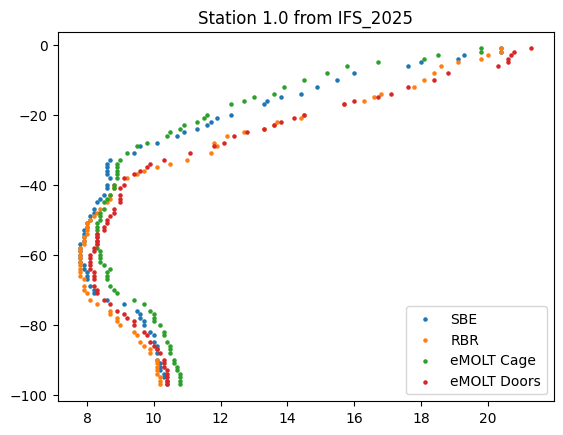

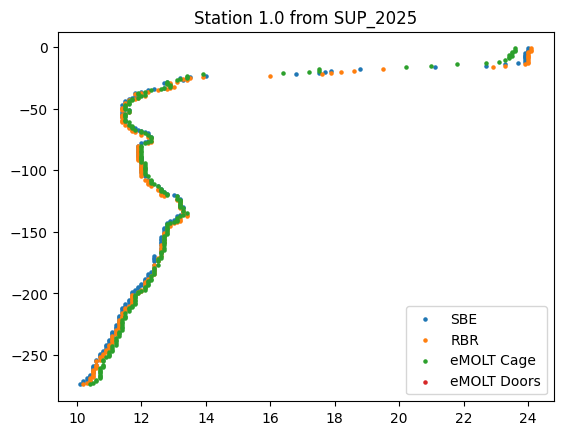

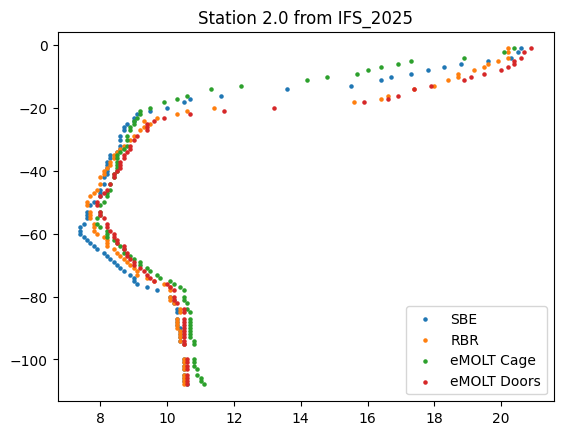

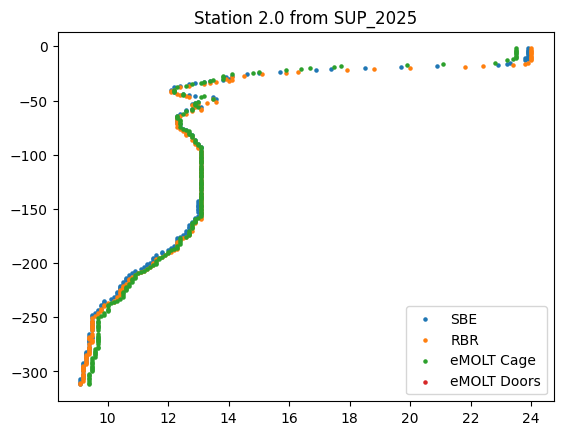

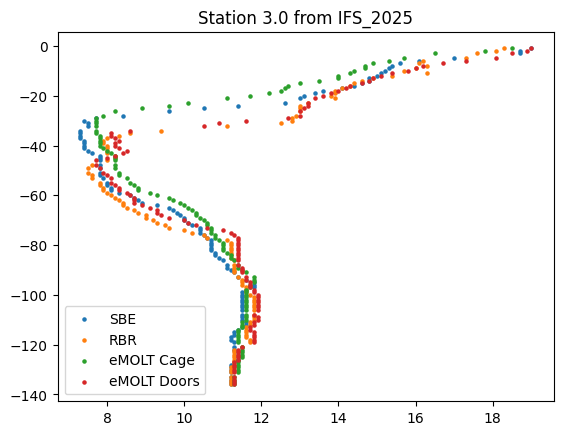

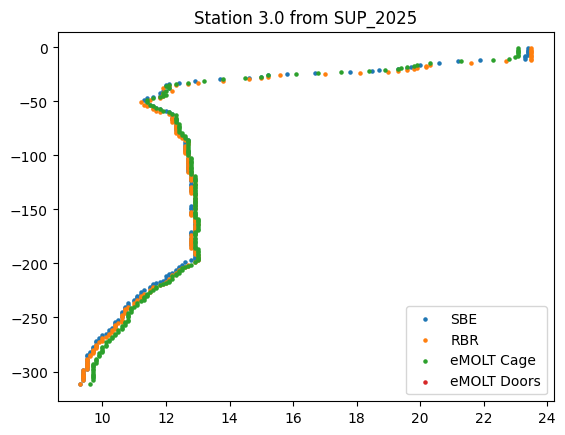

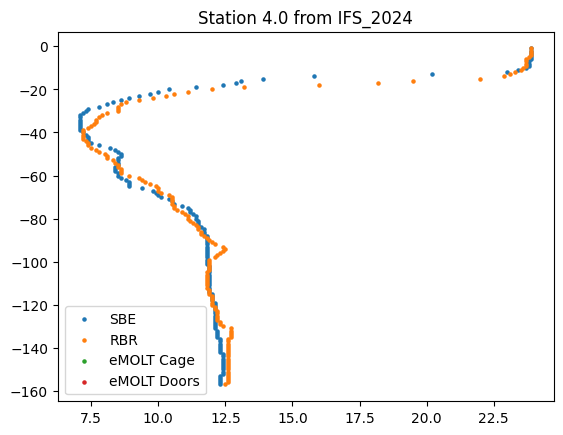

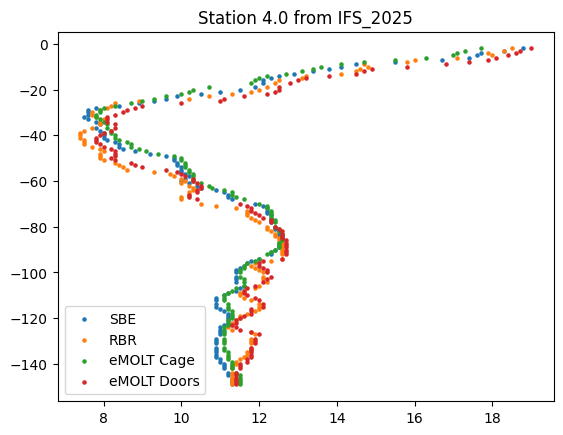

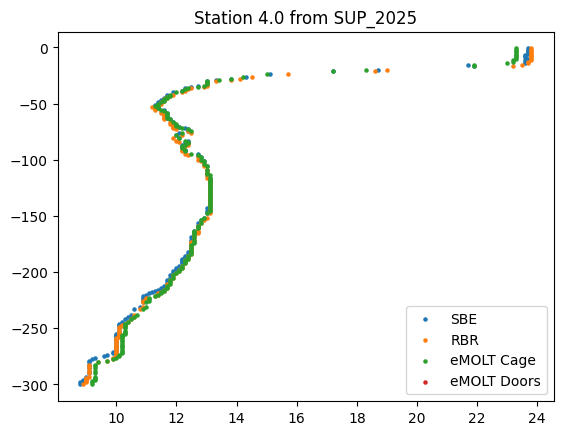

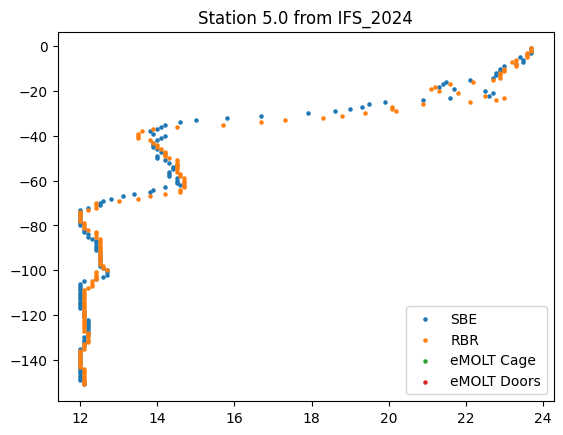

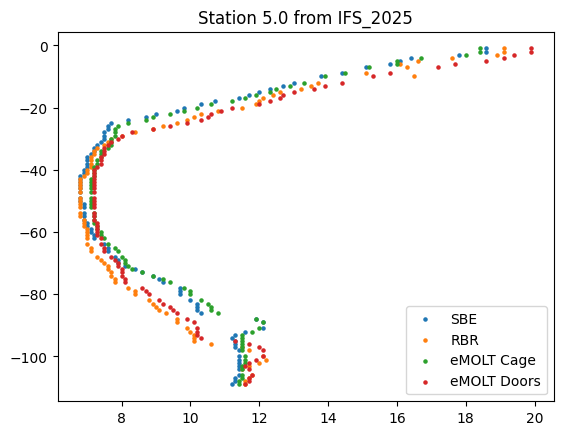

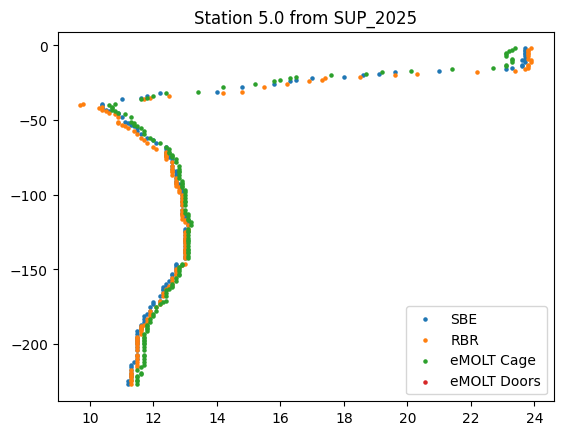

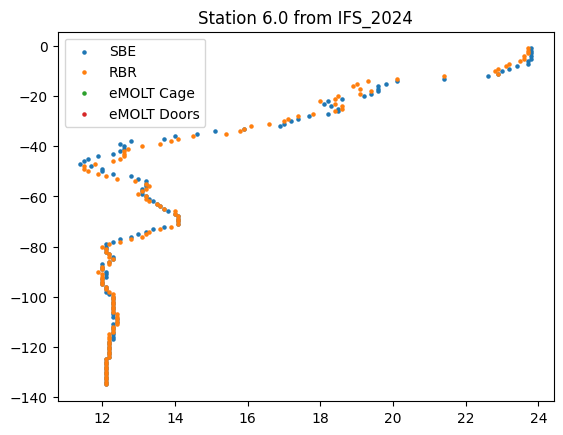

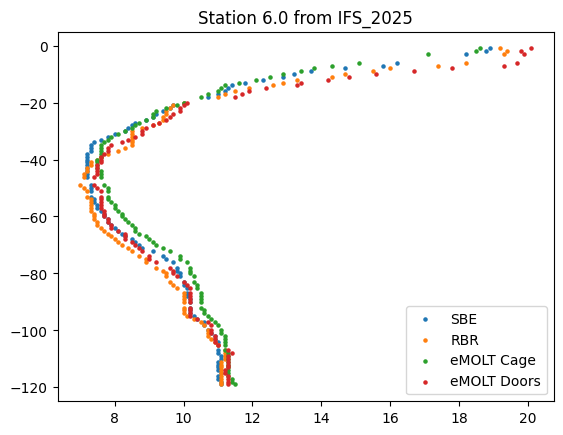

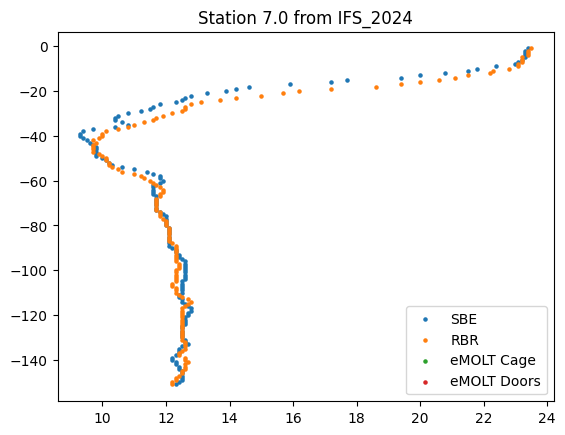

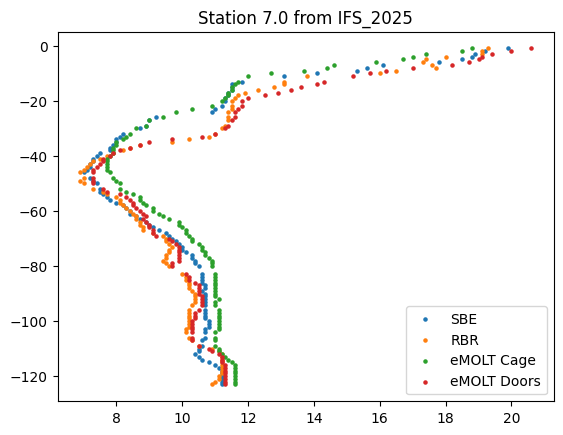

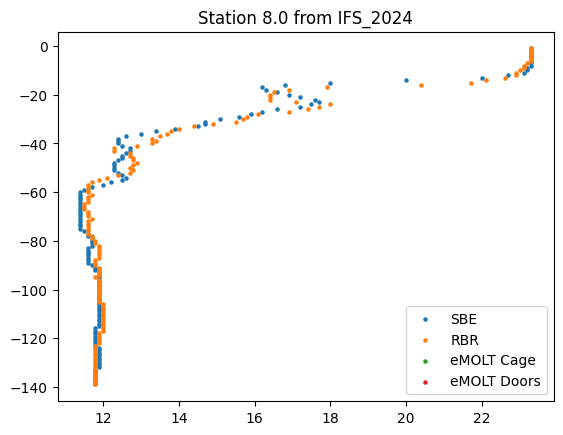

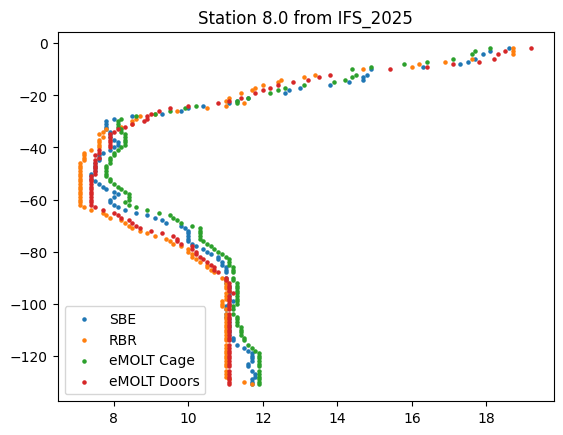

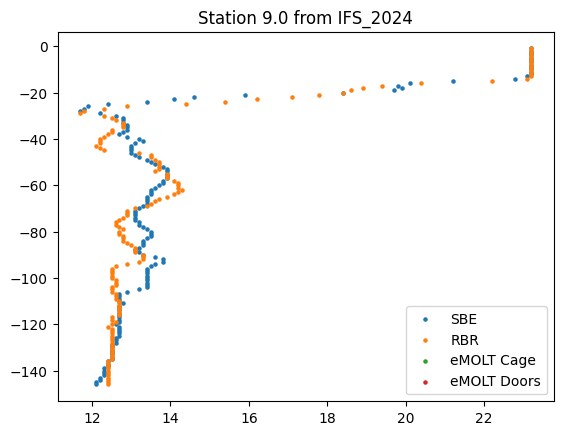

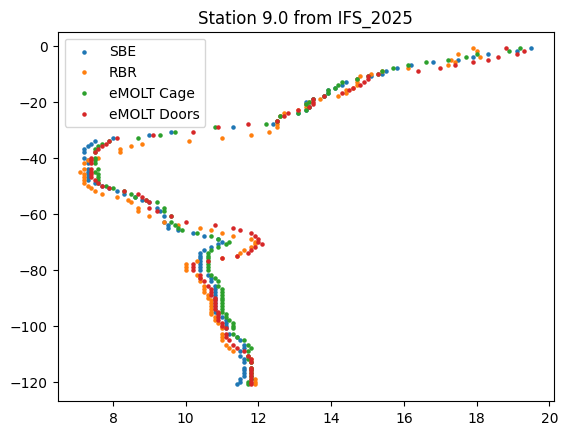

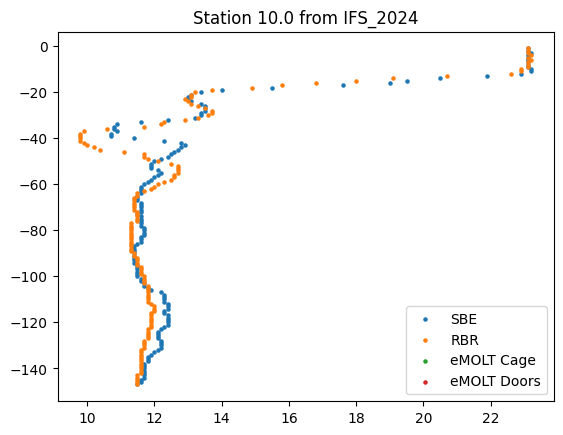

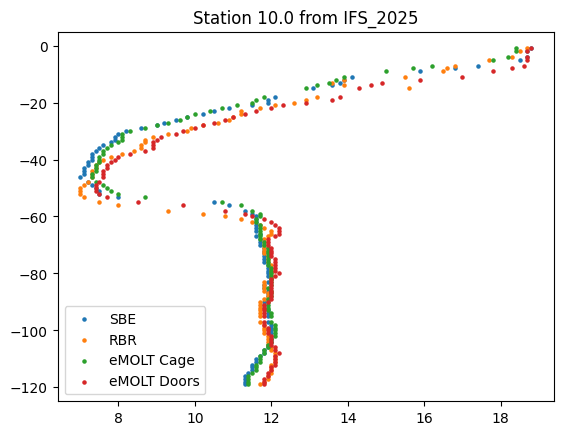

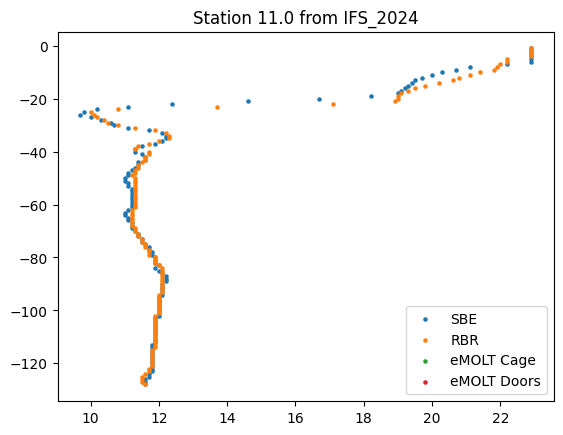

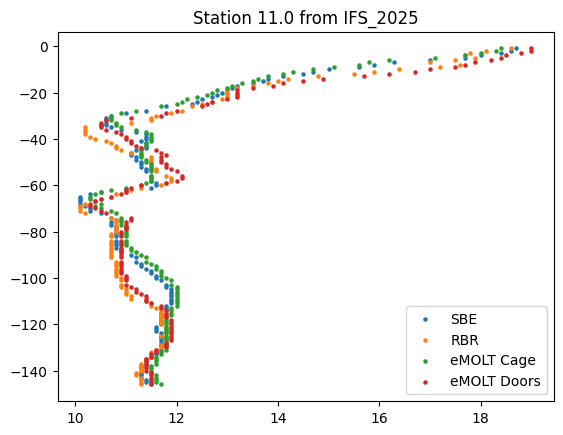

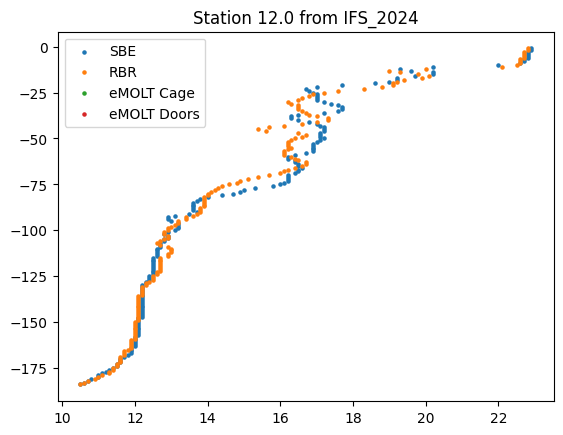

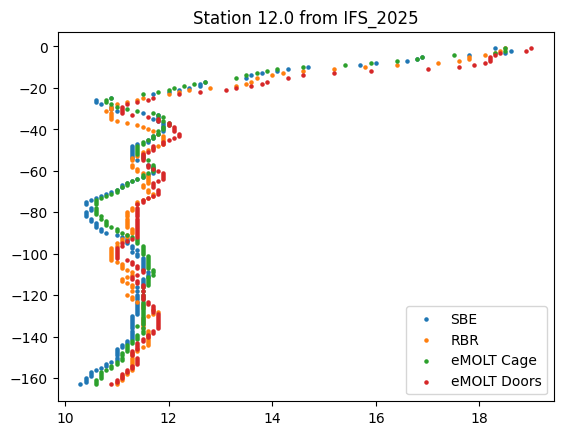

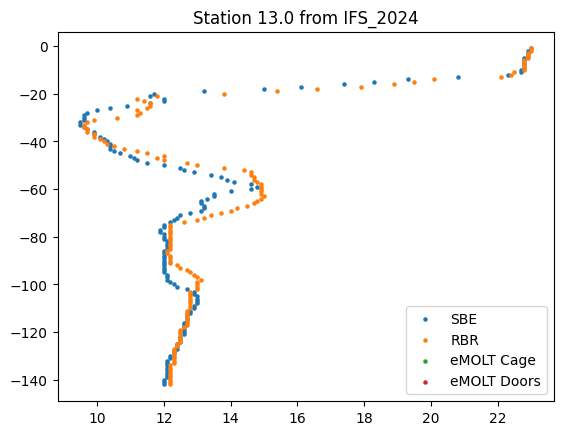

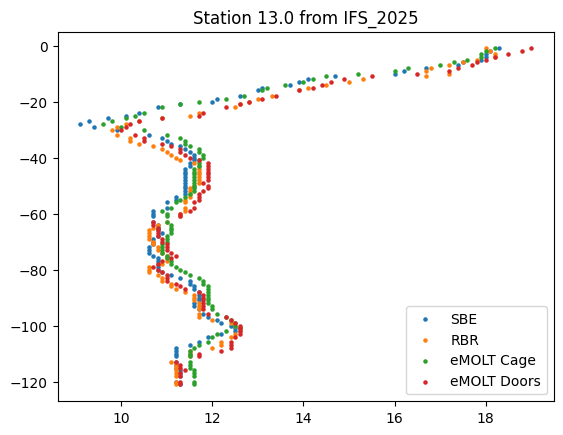

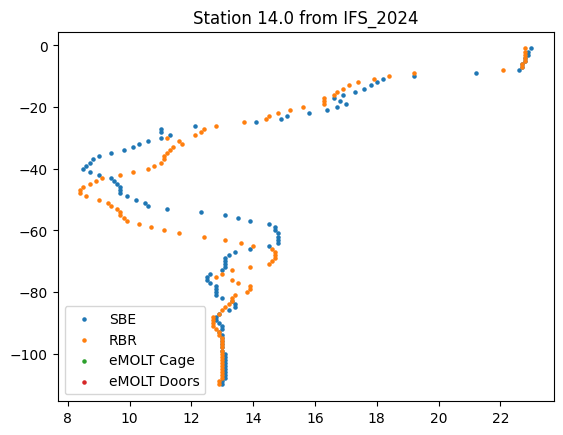

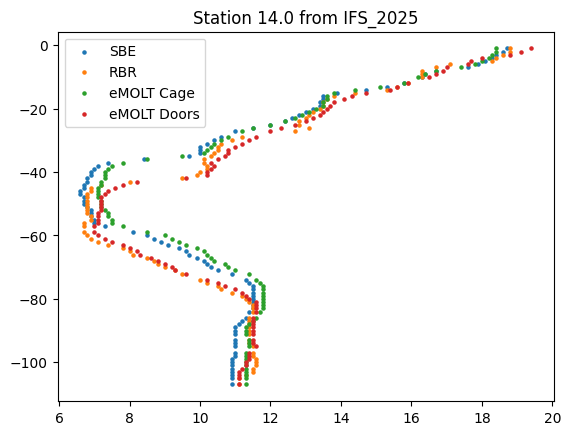

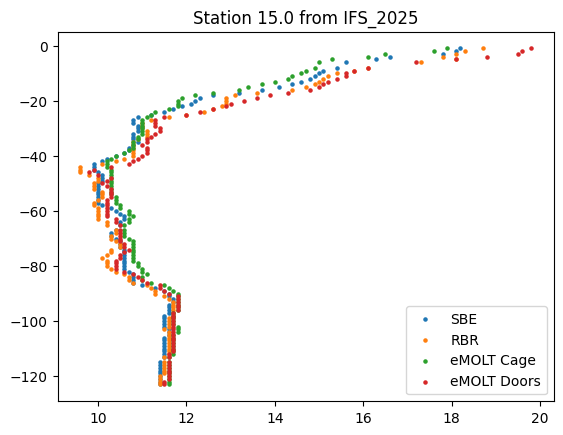

In [12]:
grouped = data.groupby(['station','cruise_ID'])
sbe_up=[]
for group_name, group_df in grouped:
    plt.scatter(group_df.temp_sbe,-group_df.binned_pres,label='SBE',s=5)
    plt.scatter(group_df.temp_rbr,-group_df.binned_pres,label='RBR',s=5)
    plt.scatter(group_df.temp_ecage,-group_df.binned_pres,label='eMOLT Cage',s=5)
    plt.scatter(group_df.temp_edoors,-group_df.binned_pres,label='eMOLT Doors',s=5)
    plt.title(f'Station {group_name[0]} from {group_name[1]}')
    plt.legend()
    plt.show()

## Profile cleaning 
From a visual assessment it looks like stations 9 and 14 from the 2024 cruise and  3, 4, 11, and 12 from the cruise in 2025 are showing some discrepancies between deployment methods. The two sensors, SBE and eMOLT, that were deployed at the same time and the RBR and eMOLT sensors on the fishing doors are similar, but there are some disagreements between the two deployment methods. We can look at the time lag and the spatial drift between the two methods, but the purpose of this paper is to compare sensor performance in similar water. To ensure we aren't introducing more of a sampling bias than necessary, we will remove these stations from the data. <br>

Text(0.5, 0.98, 'Stations to remove from study')

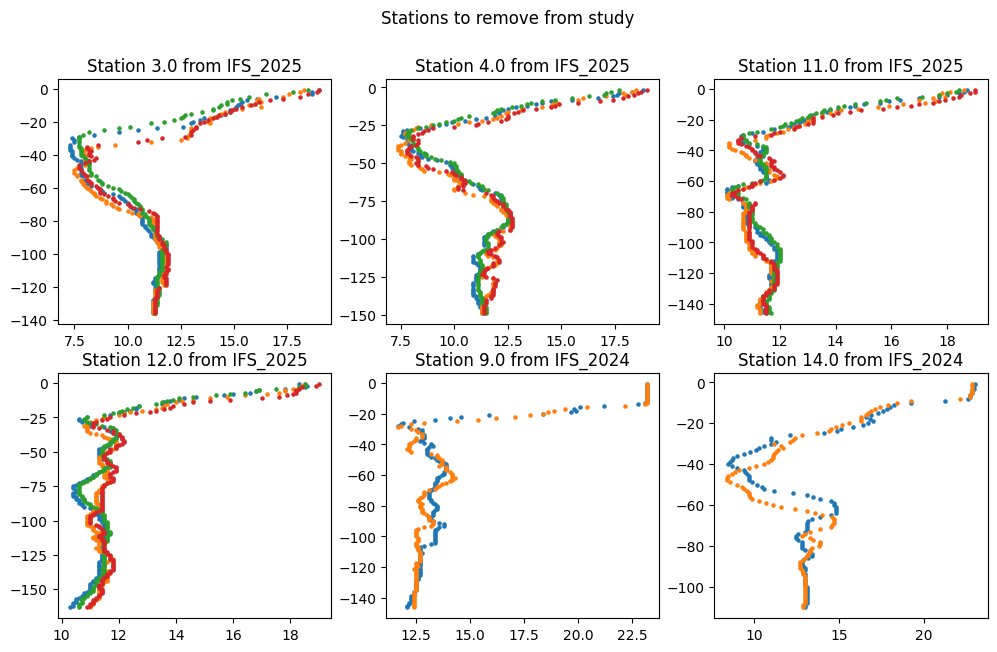

In [13]:
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(12, 7))
axes_flat = axes.flatten()
stations=[3,4,11,12,9,14]
cruise=['IFS_2025','IFS_2025','IFS_2025','IFS_2025','IFS_2024','IFS_2024']
for i, ax in enumerate(axes_flat):
    sub=data[(data.station==stations[i]) & (data.cruise_ID==cruise[i])]
    ax.scatter(sub.temp_sbe,-sub.binned_pres,label='SBE',s=5)
    ax.scatter(sub.temp_rbr,-sub.binned_pres,label='RBR',s=5)
    ax.scatter(sub.temp_ecage,-sub.binned_pres,label='eMOLT Cage',s=5)
    ax.scatter(sub.temp_edoors,-sub.binned_pres,label='eMOLT Doors',s=5)
    ax.set_title(f'Station {sub.station.iloc[0]} from {sub.cruise_ID.iloc[0]}')

plt.suptitle('Stations to remove from study',y=0.98)

### Remove stations with spatiotemporal discrepancies between methods

In [14]:
data['station'] = data.station.astype(float)
data=data.reset_index()
#DROP STATION DATA 

data = data.drop(data[(data.station==9) & (data.cruise_ID=='IFS_2024')].index)
data = data.drop(data[(data.station==14) & (data.cruise_ID=='IFS_2024')].index)

data = data.drop(data[(data.station==3) & (data.cruise_ID=='IFS_2025')].index)
data = data.drop(data[(data.station==4) & (data.cruise_ID=='IFS_2025')].index)
data = data.drop(data[(data.station==11) & (data.cruise_ID=='IFS_2025')].index)
data = data.drop(data[(data.station==12) & (data.cruise_ID=='IFS_2025')].index)

## Statistical analysis 
First we will use a Shaprio Wilk test for normality. Then we will implement pairwise Wilcoxon signed rank sum tests to check to statistical differences between sensors and deployment methods. We will run these tests on all observations as a whole, as well as individual profiles.

In [15]:
#check for statistical difference
from scipy.stats import shapiro
def check_normality(data):
    stat, p_value = shapiro(data)
    # Interpretation at a 0.05 significance level
    alpha = 0.05
    if p_value > alpha:
        print("Fail to reject the null hypothesis (data appears normally distributed).")
    else:
        print("Reject the null hypothesis (data does not appear normally distributed).")

check_normality(data.temp_sbe)
check_normality(data.temp_rbr)
check_normality(data.temp_edoors)
check_normality(data.temp_ecage)

Reject the null hypothesis (data does not appear normally distributed).
Reject the null hypothesis (data does not appear normally distributed).
Reject the null hypothesis (data does not appear normally distributed).
Reject the null hypothesis (data does not appear normally distributed).


In [16]:
#all observations
from scipy.stats import wilcoxon
def check_stat_dif(data,name1,name2): 
    data = data[[f'temp_{name1}',f'temp_{name2}']].dropna()
    stat, p = wilcoxon( data[f'temp_{name1}'],  data[f'temp_{name2}'])
    print(f"Statistic: {stat:.2f}, P-value: {p:.4f}")
    if p < 0.05:
        print("Reject the null hypothesis. There is a statistical difference")
    elif p > 0.05:
        print(f"There is NOT a statistical difference between {name1} and {name2}") 

check_stat_dif(data, 'sbe','rbr')
check_stat_dif(data,'sbe','edoors')
check_stat_dif(data,'sbe','ecage')
check_stat_dif(data,'rbr','edoors')
check_stat_dif(data,'rbr','ecage')
check_stat_dif(data,'ecage','edoors')

Statistic: 1418541.50, P-value: 0.0000
Reject the null hypothesis. There is a statistical difference
Statistic: 120242.50, P-value: 0.0000
Reject the null hypothesis. There is a statistical difference
Statistic: 383675.00, P-value: 0.0000
Reject the null hypothesis. There is a statistical difference
Statistic: 52335.50, P-value: 0.0000
Reject the null hypothesis. There is a statistical difference
Statistic: 680827.00, P-value: 0.0000
Reject the null hypothesis. There is a statistical difference
Statistic: 250016.00, P-value: 0.0085
Reject the null hypothesis. There is a statistical difference


In [ ]:
#by station
def check_stat_dif(data1, data2,name1,name2): 
    stat, p = wilcoxon(data1, data2)
    print(f"Statistic: {stat:.2f}, P-value: {p:.4f}")
    if p < 0.05:
        print("Reject the null hypothesis. There is a statistical difference")
    elif p > 0.05:
        print(f"There is NOT a statistical difference between {name1} and {name2}") 

grouped =data.groupby(['station','cruise_ID'])
for group_name, group_data in grouped:
    print(f"Group Name: {group_name}")
    check_stat_dif(group_data.temp_sbe, group_data.temp_rbr, 'sbe','rbr')
    check_stat_dif(group_data.temp_sbe, group_data.temp_edoors,'sbe','edoors')
    check_stat_dif(group_data.temp_sbe, group_data.temp_ecage,'sbe','ecage')
    check_stat_dif(group_data.temp_rbr, group_data.temp_edoors,'rbr','edoors')
    check_stat_dif(group_data.temp_rbr, group_data.temp_ecage,'rbr','ecage')
    check_stat_dif(group_data.temp_ecage, group_data.temp_edoors,'ecage','edoors')

In [17]:
print(f'Average difference between sbe and rbr is {(data.temp_sbe-data.temp_rbr).mean()} C')
print(f'Average difference between sbe and ecage is {(data.temp_sbe-data.temp_ecage).mean()} C')
print(f'Average difference between sbe and edoors is {(data.temp_sbe-data.temp_edoors).mean()} C')
print(f'Average difference between ecage and rbr is {(data.temp_ecage-data.temp_rbr).mean()} C')
print(f'Average difference between edoors and rbr is {(data.temp_edoors-data.temp_rbr).mean()} C')
print(f'Average difference between ecage and edoors is {(data.temp_ecage-data.temp_edoors).mean()} C')

Average difference between sbe and rbr is -0.12443052391799546 C
Average difference between sbe and ecage is -0.10849403122130397 C
Average difference between sbe and edoors is -0.3682842287694974 C
Average difference between ecage and rbr is -0.00771349862258951 C
Average difference between edoors and rbr is 0.2368284228769498 C
Average difference between ecage and edoors is -0.21421143847487006 C


## Bland-altman plots 
### FIGURE 1
Note use the sensor with the higher accuracy is used as the true data. RBR has the highest accuracy, and Lowell TDO-1 has the lowest. 

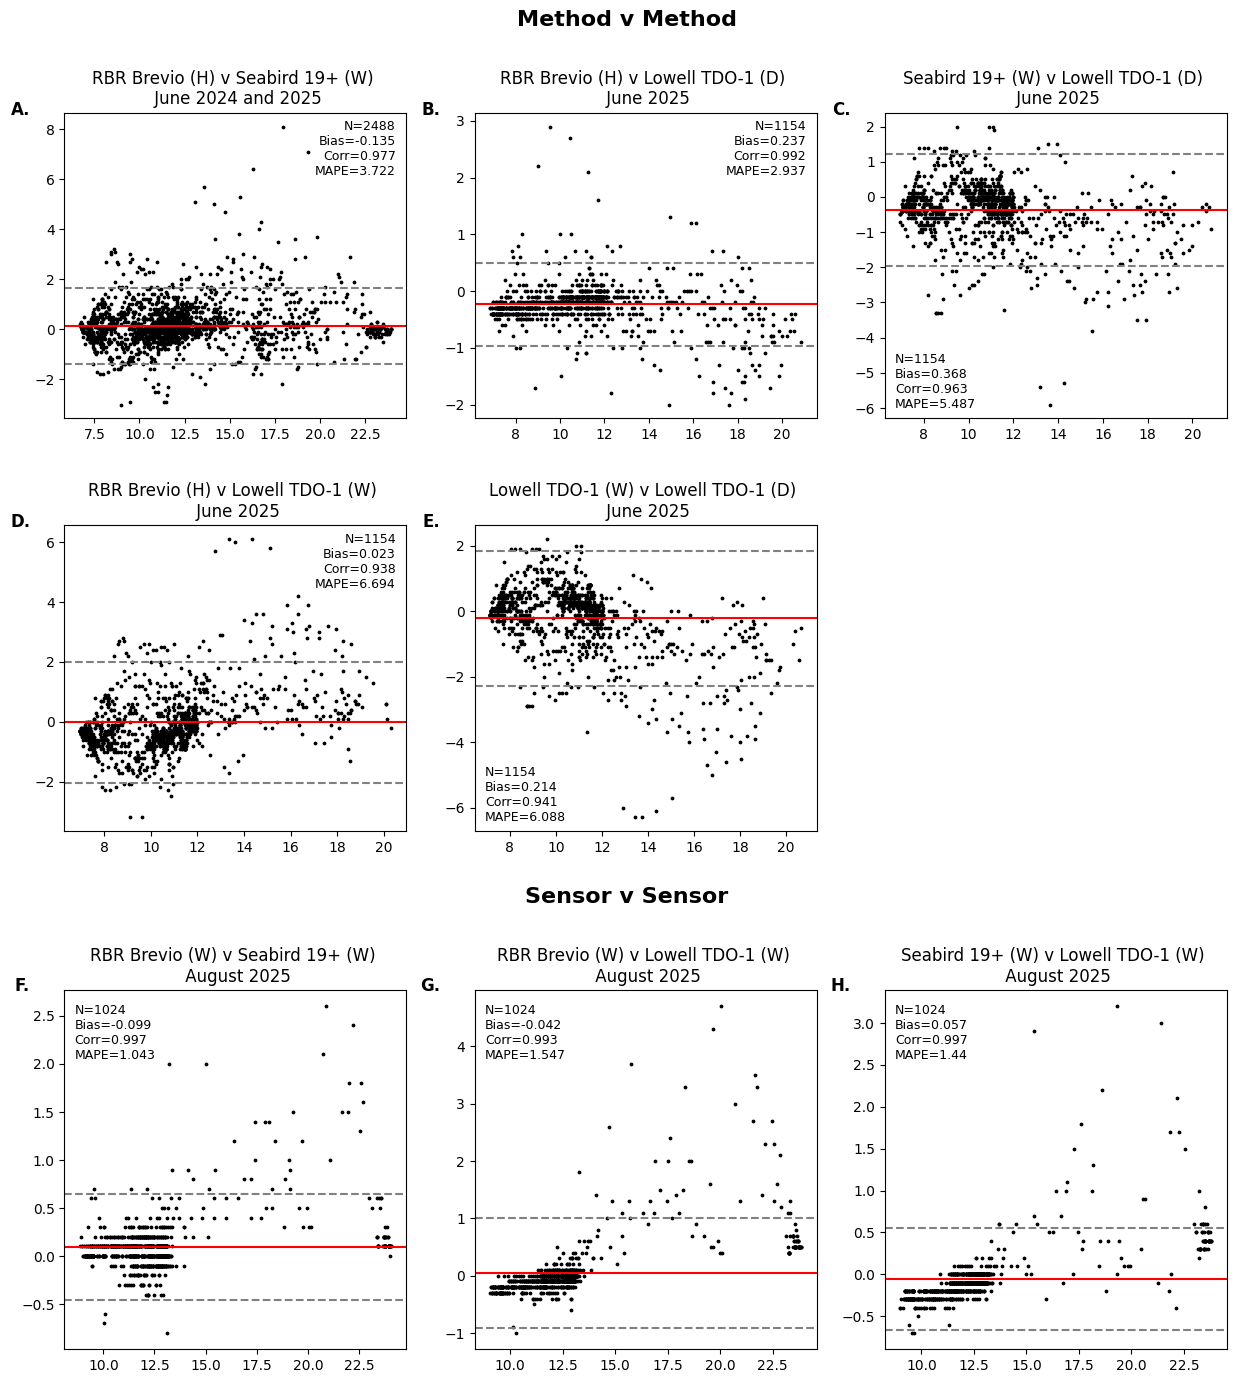

In [18]:
import matplotlib.pyplot as plt
import numpy as np

from scipy.stats import wilcoxon
from sklearn.metrics import mean_absolute_error

# 1. Create the main figure
fig = plt.figure(figsize=(15, 14),)#constrained_layout=True)

fig.subplots_adjust(hspace=0.35)

# 2. Divide the figure into two main subfigures (panels) vertically
# The height_ratios can be adjusted if one panel should be taller than the other
(topfig, bottomfig) = fig.subfigures(2, 1, height_ratios=[2, 1])

# --- Panel 1 Configuration ---
topfig.suptitle('Method v Method', fontsize=16, y=.99,fontweight='bold') # Main title for the top panel
# Define a GridSpec for the top panel: 2 rows, 3 columns
gs_top = topfig.add_gridspec(2, 3)

# Add subplots to the top panel using GridSpec
# Row 1: 3 subplots
ax1 = topfig.add_subplot(gs_top[0, 0])
ax2 = topfig.add_subplot(gs_top[0, 1])
ax3 = topfig.add_subplot(gs_top[0, 2])
# Row 2: 2 subplots spanning the 3 columns (e.g. occupying the first two columns and the last)
ax4 = topfig.add_subplot(gs_top[1, 0])
ax5 = topfig.add_subplot(gs_top[1, 1])

# PANEL 1: METHOD V METHOD
#1: SBE vs RBR for 2024 and 2025
x=data[(data.cruise_ID=='IFS_2024') | (data.cruise_ID=='IFS_2025')].temp_rbr
y=data[(data.cruise_ID=='IFS_2024') | (data.cruise_ID=='IFS_2025')].temp_sbe
differences= x-y
mean= (x+y)/2
ax1.scatter(mean, differences,s=3,c='black')
ax1.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
ax1.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
ax1.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
ax1.set_title('RBR Brevio (H) v Seabird 19+ (W) \n June 2024 and 2025')
ax1.text(0.97, 0.88, f'N={len(x)}\nBias={calculate_mbe(x,y).round(3)}\nCorr={x.corr(y).round(3)}\nMAPE={((abs(x - y) / abs(x)).mean()*100).round(3)}', horizontalalignment='right', verticalalignment='center', transform=ax1.transAxes, fontsize=9)
ax1.text(-0.1, 1.01, 'A.',horizontalalignment='right', verticalalignment='center', transform=ax1.transAxes, fontsize=12,fontweight='bold',)

#2: Emolt (D) v RBR (H) for 2025 
x=data[data.cruise_ID=='IFS_2025'].temp_rbr
y=data[data.cruise_ID=='IFS_2025'].temp_edoors
differences= x-y
mean= (x+y)/2
ax2.scatter(mean, differences,s=3,c='black')
ax2.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
ax2.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
ax2.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
ax2.set_title('RBR Brevio (H) v Lowell TDO-1 (D) \n June 2025')
ax2.text(0.97, 0.88, f'N={len(x)}\nBias={calculate_mbe(x,y).round(3)}\nCorr={x.corr(y).round(3)}\nMAPE={((abs(x - y) / abs(x)).mean()*100).round(3)}', horizontalalignment='right', verticalalignment='center', transform=ax2.transAxes, fontsize=9)
ax2.text(-0.1, 1.01, 'B.',horizontalalignment='right', verticalalignment='center', transform=ax2.transAxes, fontsize=12,fontweight='bold',)

#3: Emolt (D) v SBE (w) for 2025 
x=data[data.cruise_ID=='IFS_2025'].temp_sbe
y=data[data.cruise_ID=='IFS_2025'].temp_edoors
differences= x-y
mean= (x+y)/2
ax3.scatter(mean, differences,s=3,c='black')
ax3.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
ax3.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
ax3.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
ax3.set_title('Seabird 19+ (W) v Lowell TDO-1 (D) \n June 2025')
ax3.text(0.03, 0.12, f'N={len(x)}\nBias={calculate_mbe(x,y).round(3)}\nCorr={x.corr(y).round(3)}\nMAPE={((abs(x - y) / abs(x)).mean()*100).round(3)}', horizontalalignment='left', verticalalignment='center', transform=ax3.transAxes, fontsize=9)
ax3.text(-0.1, 1.01, 'C.',horizontalalignment='right', verticalalignment='center', transform=ax3.transAxes, fontsize=12,fontweight='bold',)

#4: Emolt (W) v RBR (H) for 2025 
x=data[data.cruise_ID=='IFS_2025'].temp_rbr
y=data[data.cruise_ID=='IFS_2025'].temp_ecage
differences= x-y
mean= (x+y)/2
ax4.scatter(mean, differences,s=3,c='black')
ax4.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
ax4.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
ax4.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
ax4.set_title('RBR Brevio (H) v Lowell TDO-1 (W) \n June 2025')
ax4.text(0.97, 0.88, f'N={len(x)}\nBias={calculate_mbe(x,y).round(3)}\nCorr={x.corr(y).round(3)}\nMAPE={((abs(x - y) / abs(x)).mean()*100).round(3)}', horizontalalignment='right', verticalalignment='center', transform=ax4.transAxes, fontsize=9)
ax4.text(-0.1, 1.01, 'D.',horizontalalignment='right', verticalalignment='center', transform=ax4.transAxes, fontsize=12,fontweight='bold',)

#5: Emolt (D) v emolt (W) for 2025 
x=data[data.cruise_ID=='IFS_2025'].temp_ecage
y=data[data.cruise_ID=='IFS_2025'].temp_edoors
differences= x-y
mean= (x+y)/2
ax5.scatter(mean, differences,s=3,c='black')
ax5.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
ax5.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
ax5.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
ax5.set_title('Lowell TDO-1 (W) v Lowell TDO-1 (D) \n June 2025')
ax5.text(0.03, 0.12, f'N={len(x)}\nBias={calculate_mbe(x,y).round(3)}\nCorr={x.corr(y).round(3)}\nMAPE={((abs(x - y) / abs(x)).mean()*100).round(3)}', horizontalalignment='left', verticalalignment='center', transform=ax5.transAxes, fontsize=9)
ax5.text(-0.1, 1.01, 'E.',horizontalalignment='right', verticalalignment='center', transform=ax5.transAxes, fontsize=12,fontweight='bold',)

# PANEL 2: SENSOR V SENSOR 
bottomfig.suptitle('Sensor v Sensor', fontsize=16, y=1.1, fontweight='bold') # Main title for the bottom panel
# Define a GridSpec for the bottom panel: 1 row, 3 columns
gs_bottom = bottomfig.add_gridspec(1, 3)

# Add subplots to the bottom panel
ax6 = bottomfig.add_subplot(gs_bottom[0, 0])
ax7 = bottomfig.add_subplot(gs_bottom[0, 1])
ax8 = bottomfig.add_subplot(gs_bottom[0, 2])

# Plot sample data on Panel 2 axes
#6: SBE (W) v RBR (W) for Aug 2025
x=data[data.cruise_ID=='SUP_2025'].temp_rbr
y=data[data.cruise_ID=='SUP_2025'].temp_sbe
differences= x-y
mean= (x+y)/2
ax6.scatter(mean, differences,s=3,c='black')
ax6.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
ax6.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
ax6.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
ax6.set_title('RBR Brevio (W) v Seabird 19+ (W) \n August 2025')
ax6.text(0.03, 0.88, f'N={len(x)}\nBias={calculate_mbe(x,y).round(3)}\nCorr={x.corr(y).round(3)}\nMAPE={((abs(x - y) / abs(x)).mean()*100).round(3)}', horizontalalignment='left', verticalalignment='center', transform=ax6.transAxes, fontsize=9)
ax6.text(-0.1, 1.01, 'F.',horizontalalignment='right', verticalalignment='center', transform=ax6.transAxes, fontsize=12,fontweight='bold',)

#7: RBR (W) v emolt (W) for Aug 2025
x=data[data.cruise_ID=='SUP_2025'].temp_rbr
y=data[data.cruise_ID=='SUP_2025'].temp_ecage
differences= x-y
mean= (x+y)/2
ax7.scatter(mean, differences,s=3,c='black')
ax7.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
ax7.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
ax7.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
ax7.set_title('RBR Brevio (W) v Lowell TDO-1 (W) \n August 2025')
ax7.text(0.03, 0.88, f'N={len(x)}\nBias={calculate_mbe(x,y).round(3)}\nCorr={x.corr(y).round(3)}\nMAPE={((abs(x - y) / abs(x)).mean()*100).round(3)}', horizontalalignment='left', verticalalignment='center', transform=ax7.transAxes, fontsize=9)
ax7.text(-0.1, 1.01, 'G.',horizontalalignment='right', verticalalignment='center', transform=ax7.transAxes, fontsize=12,fontweight='bold',)

#8: SBE (W) v emolt (W) for Aug 2025
x=data[data.cruise_ID=='SUP_2025'].temp_sbe
y=data[data.cruise_ID=='SUP_2025'].temp_ecage
differences= x-y
mean= (x+y)/2
ax8.scatter(mean, differences,s=3,c='black')
ax8.axhline(np.mean(differences), color='red', linestyle='-', label='Mean Diff')
ax8.axhline(np.mean(differences) + 1.96*np.std(differences), color='gray', linestyle='--', label='Limits of agreement')
ax8.axhline(np.mean(differences) - 1.96*np.std(differences), color='gray', linestyle='--')
ax8.set_title('Seabird 19+ (W) v Lowell TDO-1 (W) \n August 2025')
ax8.text(0.03, 0.88, f'N={len(x)}\nBias={calculate_mbe(x,y).round(3)}\nCorr={x.corr(y).round(3)}\nMAPE={((abs(x - y) / abs(x)).mean()*100).round(3)}', horizontalalignment='left', verticalalignment='center', transform=ax8.transAxes, fontsize=9)
#fig.text(0.1,.00005, "Figure 2: Bland altman plots for pairwise measurements by deployment method (top panel) and pairwise sensor measurements with the same deployment method (bottom panel). \nDeployment methods are depicted as: Winch (W), Headrope (H), Doors (D). The mean bias line is represented as the solid red line. \nThe upper and lower limit of agreement lines (95% confidence intervals) are shown as gray dashed lines.", ha='left', fontsize=10)
#plt.tight_layout()
#fig.subplots_adjust(top=.9,bottom=0.1)
#fig.subplots_adjust(bottom=0.3)
#topfig.subplots_adjust(bottom=0.92)
ax8.text(-0.1, 1.01, 'H.',horizontalalignment='right', verticalalignment='center', transform=ax8.transAxes, fontsize=12,fontweight='bold',)


plt.show()

#fig.savefig(r'C:\Users\haley.synan\Documents\PROJECTS\sensor_comps\FIGURES\figure1.jpg', bbox_inches='tight', dpi=900)